# House Price Prediction Using Stacking Ensembles

**COMP4131 Data Modelling and Analysis**  
**Author:** Yuyang Zhang (20514470)

The notebook is the full data modelling pipeline for predicting house prices on the King County housing dataset. Results in this notebook reproduce those reported in the accompanying paper.

## Reproducibility

Place `data.csv` in the same folder as this notebook and run all cells from top to bottom. A fixed random seed (`42`) is used throughout.

## Dependencies

Python 3.9+ is recommended. Install dependencies with:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm
```

Specifically, the following libraries are used:

| Library | Purpose |
|---|---|
| `pandas`, `numpy` | Data manipulation |
| `matplotlib`, `seaborn` | Visualisation |
| `scikit-learn` | Preprocessing, model training, evaluation, cross-validation |
| `xgboost` | Gradient-boosted tree base learner |
| `lightgbm` | LightGBM gradient-boosted tree base learner |

## Notebook Structure

1. Environment setup and data loading  
2. Exploratory data analysis (EDA)  
3. Outlier removal and feature engineering  
4. Train–test split, target encoding, hybrid feature selection, scaling  
5. Baseline model training and evaluation  
6. Stacking ensemble construction (three meta-learner variants)  
7. Ablation study and feature-importance analysis  
8. Residual diagnostics and consolidated paper figures


# Part 1 Environment Setup

The follwoing section initialises the environment and imports the needed library.

### Libraries Used
- Data manipulation: `pandas`, `numpy`  
- Visualisation: `matplotlib`, `seaborn`  
- Modelling: `scikit-learn`, `xgboost`, `lightgbm`  
- Evaluation: RMSE, MAE, and $R^2$  
- Validation: cross-validation and K-Fold   

### Models
- Linear: Ridge  
- Tree-based: Random Forest, Extra Trees, Gradient Boosting  
- Boosting: XGBoost, LightGBM    

### Reproducibility
A fixed random seed is used, warnings are suppressed, and visualisation settings are standardised to ensure consistent and reproducible results.

In [1]:
# Standard scientific stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
# Modelling utilities
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
# Models
from sklearn.linear_model import Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Cosmetic settings
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')


# Part 2 — Data Loading and Initial Inspection

Load the King County housing dataset from a relative path, inspect its shape and dtypes, and check for missing values.

## Data Loading and Initial Inspection

The dataset is loaded from a CSV file and a working copy is created to preserve the original data.

An initial inspection is conducted, including:

The shape of the dataset
A preview of the first 5 records
Data types of each feature
Summary statistics of variables



In [2]:
df_original = pd.read_csv('data.csv')
df = df_original.copy()
print('Shape:', df.shape)
display(df.head())
df.info()
display(df.describe())

Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## Missing Value Analysis

The following block is used to check for missing values in the dataset. Only columns with missing values are displayed.

In [3]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
missing = pd.concat([null_counts, null_pct], axis=1, keys=['Count', 'Pct'])
missing = missing[missing['Count'] > 0].sort_values('Pct', ascending=False)
print('Missing values:')
display(missing if len(missing) > 0 else 'No missing values')

Missing values:


'No missing values'

# Part 3 — Exploratory Data Analysis (EDA)
The following section covers the EDA, with specific aim and usage in markdown cell in each block

## Distribution of Target Variable (Price)

Here, I visualised the distribution of house prices and calculated the skewness of the target variable.


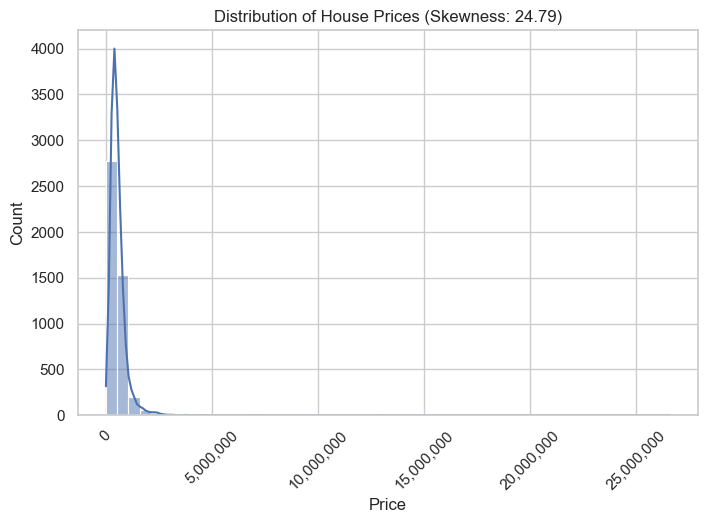

In [4]:
price_skew = df['price'].skew()
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f'Distribution of House Prices (Skewness: {price_skew:.2f})')
plt.xlabel('Price')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Relationship Between Key Features and House Price

The following cell explored the relationships between selected features and house prices.
1) Regression is used to examine the relationship between `sqft_living` and price.
2) Boxplots are used to analyse the effect of `waterfront` and `view` on house prices.


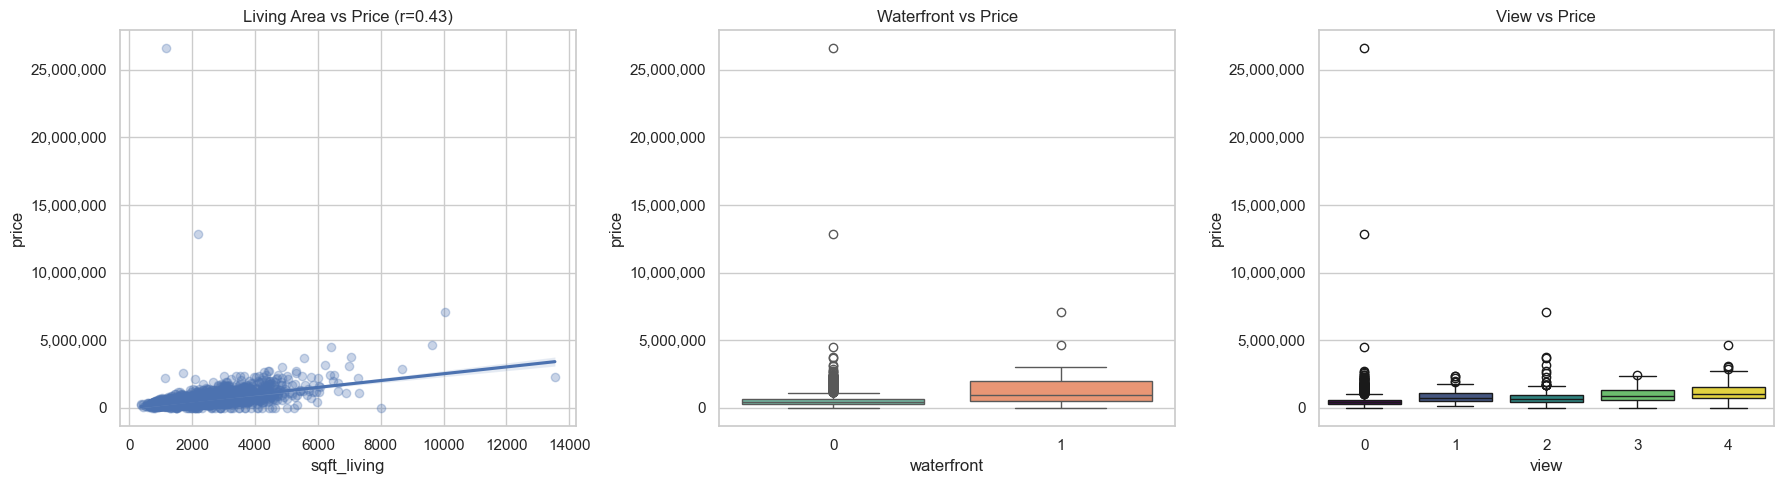

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='sqft_living', y='price', data=df, scatter_kws={'alpha': 0.3}, ax=axes[0])
axes[0].set_title(f'Living Area vs Price (r={df["sqft_living"].corr(df["price"]):.2f})')

sns.boxplot(x='waterfront', y='price', data=df, hue='waterfront', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Waterfront vs Price')

sns.boxplot(x='view', y='price', data=df, hue='view', palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('View vs Price')

for ax in axes:
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig('eda_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlation Analysis

The following cell is using a heatmap to show the correlation matrix of numerical features:
1） Identify features strongly correlated with the target variable (`price`)
2） Detect potential multicollinearity between input features

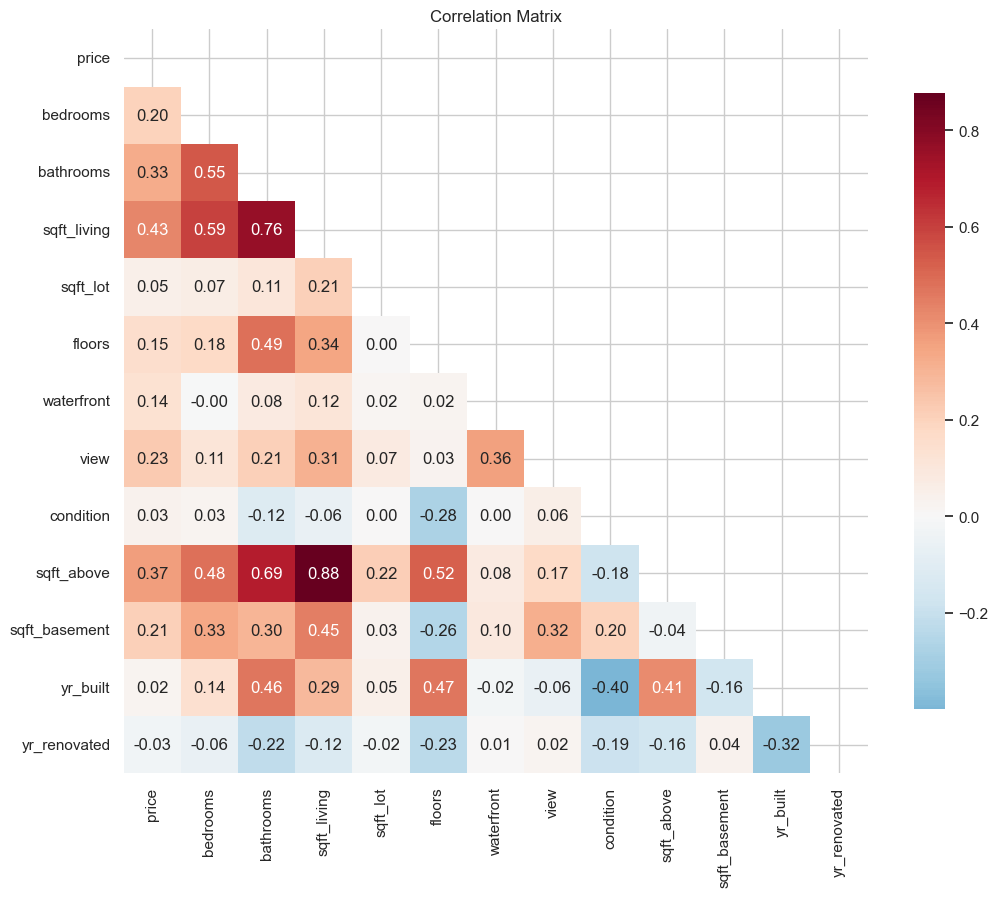

In [6]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix')
plt.show()

## Average House Price by City

The following cell is used to check the average house price across different cities and the bar plot is chosen for the visualization (in descending order)


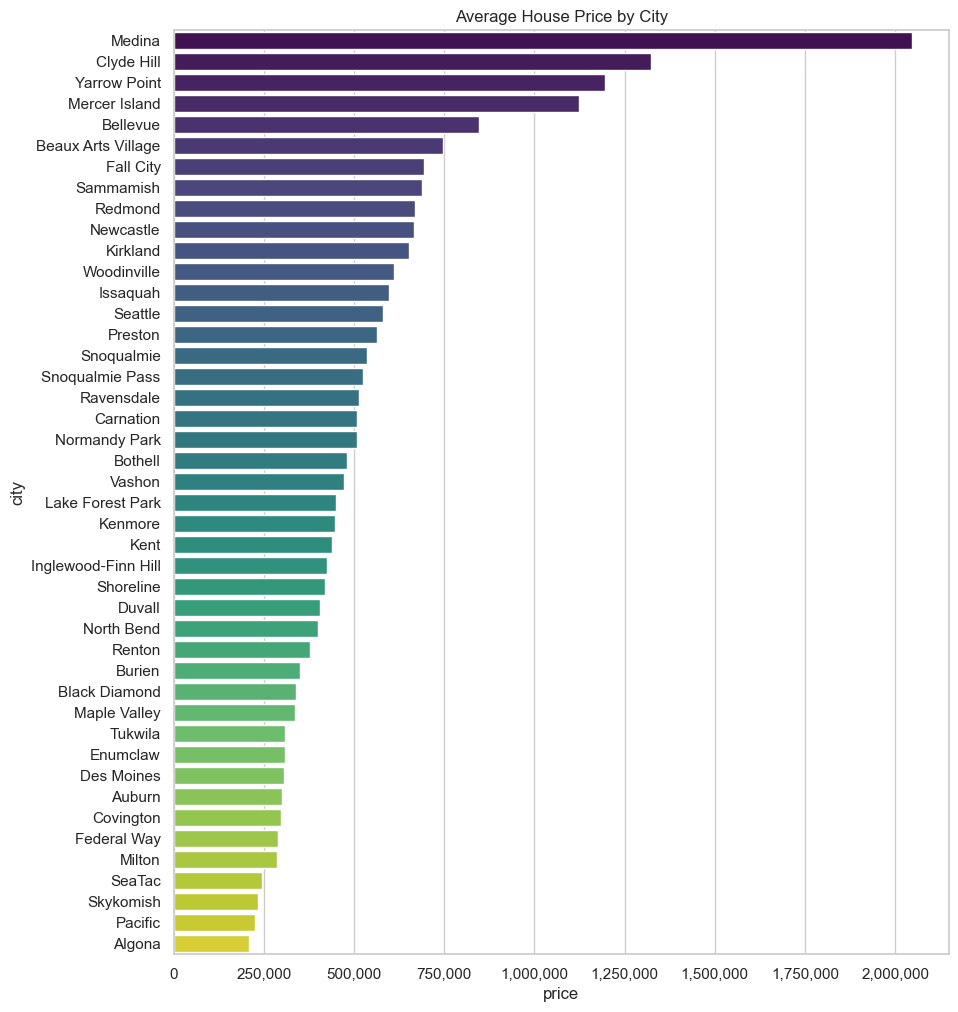

In [7]:
city_order = df.groupby('city')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(
    x='price', y='city',
    data=df,
    order=city_order,
    palette='viridis',
    estimator='mean',
    ci=None,               
)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title('Average House Price by City')
plt.savefig('city_price.png', dpi=300, bbox_inches='tight')
plt.show()

# Part 4 — Data Cleaning and Preprocessing
The following section is for data cleaning and preprocessing, detailed usage please refer to the markdown cells.

## Outlier Removal

Specifically, observations above the 99th percentile are filtered out. To check the effect, boxplots are used to compare the distribution of house prices before and after filtering.

## Removing Zero-Price Rows

The raw dataset contains a small number of rows with `price = 0`. These appear to be data-entry errors rather than valid observations and are removed before any further preprocessing for two reasons:

1. They distort the price distribution and bias outlier statistics.
2. After log-transforming the target, they would map to `log(1) = 0`, far below the rest of the distribution, and would dominate the loss in log-space training.

In [8]:
# Drop rows with price = 0 (data-entry errors).
n_zero = (df['price'] == 0).sum()
print(f'Rows with price = 0: {n_zero}')

if n_zero > 0:
    df = df[df['price'] > 0].reset_index(drop=True)
    print(f'After removing zero-price rows: {df.shape[0]} rows remain')

Rows with price = 0: 49
After removing zero-price rows: 4551 rows remain


Removed 46 outliers (1.0%), 4505 rows remain


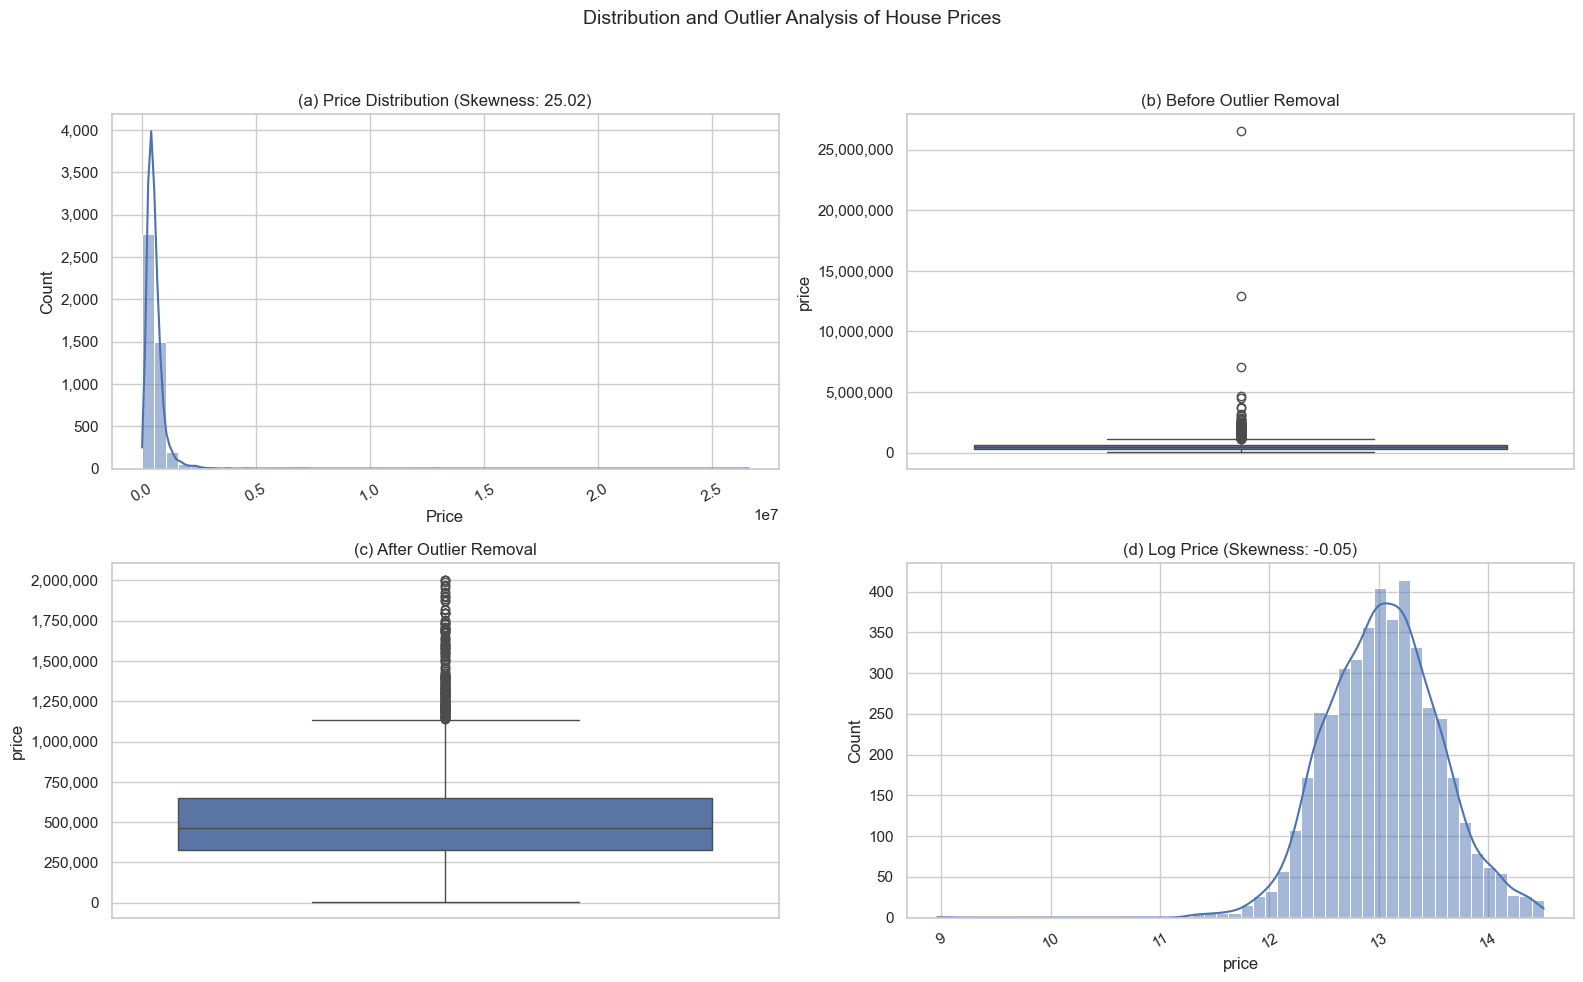

In [9]:
# Outlier removal: drop the top 1% of prices to reduce skew
original_size = df.shape[0]
df_cleaned = df[df['price'] < df['price'].quantile(0.99)].copy()
removed = original_size - df_cleaned.shape[0]
print(f'Removed {removed} outliers ({removed/original_size*100:.1f}%), {df_cleaned.shape[0]} rows remain')

log_price = np.log1p(df['price'])
log_price_cleaned = np.log1p(df_cleaned['price'])

# Consolidated figure: distribution + before/after boxplots (used as Fig. 1 in the paper)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Original price distribution with kernel density estimate
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title(f'(a) Price Distribution (Skewness: {df["price"].skew():.2f})')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Count')

# (b) Before outlier removal
sns.boxplot(y=df['price'], ax=axes[0, 1])
axes[0, 1].set_title('(b) Before Outlier Removal')

# (c) After outlier removal
sns.boxplot(y=df_cleaned['price'], ax=axes[1, 0])
axes[1, 0].set_title('(c) After Outlier Removal')

# (d) Log price distribution 
sns.histplot(log_price_cleaned, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title(f'(d) Log Price (Skewness: {log_price_cleaned.skew():.2f})')

for ax in axes.flatten():
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Distribution and Outlier Analysis of House Prices', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('price_outlier_log_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Part 5 — Feature Engineering and Transformation

## Feature Engineering

The following section is for the following features: 

### Temporal Features
1) `year` and `month` are extracted from the transaction date
2) A categorical `season` feature is derived from `month`

### Structural Features
1) `house_age`: difference between transaction year and construction year
2) `is_renovated`: binary indicator of whether the property has been renovated
3) `years_since_renovation`: measures how recent the renovation occurred

### Ratio-Based Features
1) `basement_ratio`: proportion of basement area relative to living area
2）`bath_bed_ratio`: ratio of bathrooms to bedrooms
3) `has_basement`: binary indicator for basement presence
To avoid division by zero, a small constant is added when computing ratios


In [10]:
df_fe = df_cleaned.copy()
df_fe['date'] = pd.to_datetime(df_fe['date'])
df_fe['year'] = df_fe['date'].dt.year
df_fe['month'] = df_fe['date'].dt.month

df_fe['house_age'] = df_fe['year'] - df_fe['yr_built']
df_fe['is_renovated'] = (df_fe['yr_renovated'] > 0).astype(int)
df_fe['years_since_renovation'] = np.where(df_fe['yr_renovated'] > 0, df_fe['year'] - df_fe['yr_renovated'], 0)

EPS = 1e-6
df_fe['basement_ratio'] = df_fe['sqft_basement'] / (df_fe['sqft_living'] + EPS)
df_fe['has_basement'] = (df_fe['sqft_basement'] > 0).astype(int)
df_fe['bath_bed_ratio'] = df_fe['bathrooms'] / (df_fe['bedrooms'] + EPS)

season_map = {12:'winter',1:'winter',2:'winter',3:'spring',4:'spring',5:'spring',
              6:'summer',7:'summer',8:'summer',9:'autumn',10:'autumn',11:'autumn'}
df_fe['season'] = df_fe['month'].map(season_map)

print('Engineered features added')
print(df_fe[['house_age','is_renovated','years_since_renovation','basement_ratio','has_basement','bath_bed_ratio','season']].head())

Engineered features added
   house_age  is_renovated  years_since_renovation  basement_ratio  \
0         59             1                       9        0.000000   
2         48             0                       0        0.000000   
3         51             0                       0        0.500000   
4         38             1                      22        0.412371   
5         76             1                      20        0.000000   

   has_basement  bath_bed_ratio  season  
0             0        0.500000  spring  
2             0        0.666666  spring  
3             1        0.750000  spring  
4             1        0.625000  spring  
5             0        0.500000  spring  


## Evaluation of Engineered Features
The relationships between engineered features and house prices are calculated.

1) **House Age vs Price:**   how property age relates to price  
2) **Renovation Effect:**  average prices between renovated and non-renovated properties  
3) **Seasonal Effect:**  how average house prices vary across different seasons  



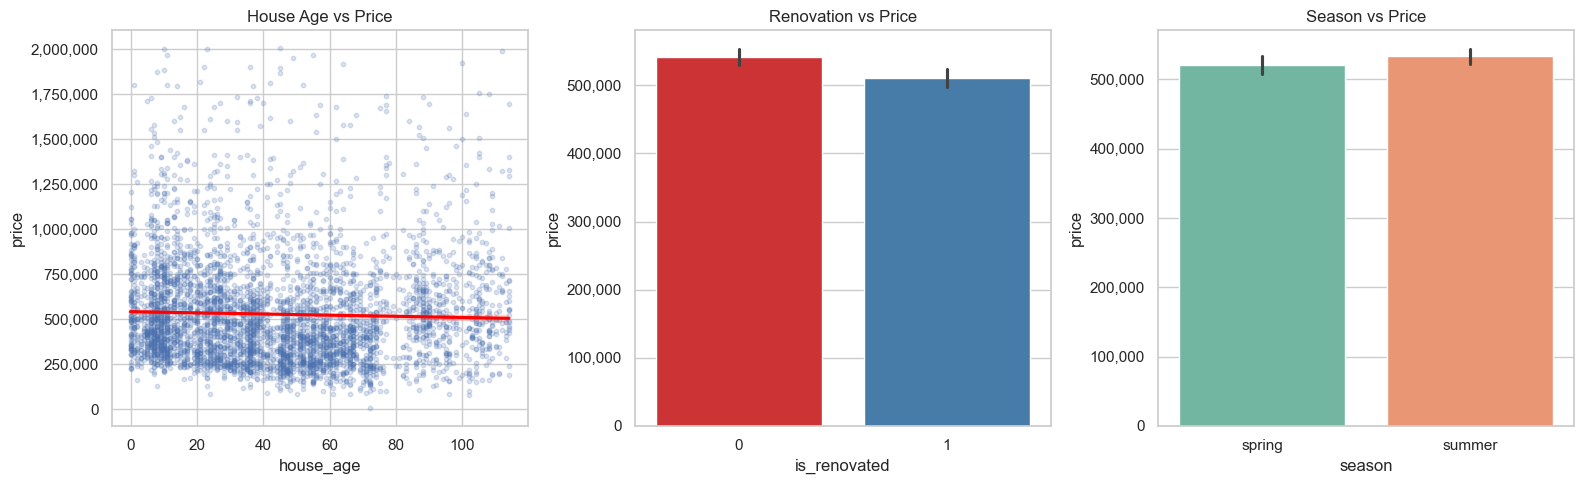

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.regplot(x='house_age', y='price', data=df_fe, scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('House Age vs Price')

sns.barplot(x='is_renovated', y='price', data=df_fe, hue='is_renovated', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title('Renovation vs Price')

sns.barplot(x='season', y='price', data=df_fe, hue='season', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Season vs Price')

for ax in axes:
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig('feature_engineering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Preparation of Modelling Dataset

The following two steps are introduced to prepare the final model training

### Feature Removal
Irrelevant or redundant features are removed, including:
1) identifiers (e.g., `street`)
2) raw variables replaced by engineered features (e.g., `date`, `yr_built`, `yr_renovated`)
3) location features handled separately (e.g., `city`, `statezip`)

### Encoding
1) The categorical feature `season` is converted into numerical form using one-hot encoding
1) Boolean variables are transformed into binary (0/1) values 


In [12]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=['street', 'country', 'date', 'sqft_above', 'sqft_basement',
             'yr_built', 'yr_renovated', 'year', 'month', 'city', 'statezip'],
    errors='ignore'
)

df_model = pd.get_dummies(df_model, columns=['season'], drop_first=True)
df_model = df_model.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)

print('Shape after encoding:', df_model.shape)
print('Columns:', df_model.columns.tolist())

Shape after encoding: (4505, 16)
Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'house_age', 'is_renovated', 'years_since_renovation', 'basement_ratio', 'has_basement', 'bath_bed_ratio', 'season_summer']


## Target Encoding for Location Features

To effectively incorporate location-based information, target encoding is applied to high-cardinality features.


### City Encoding
A similar approach is applied to the `city` feature:

- The average price per city is computed from the training set
- The resulting values are mapped to create a new feature (`city_te`)

### Rationale
Target encoding allows high-cardinality categorical variables to be represented in a compact and informative way, avoiding the high dimensionality of one-hot encoding.


## Train-Test Split

The dataset is divided into input features (`X`) and target variable (`y`), where `price` is used as the prediction target.
An 80/20 train-test split is applied to separate the data into training and testing sets.

In [13]:
X = df_model.drop(columns=['price'])
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (3604, 15) Test: (901, 15)


## Log-Transforming the Target

House prices are heavily right-skewed even after the 99th-percentile filter, which makes RMSE-based learning sensitive to high-priced observations. To stabilise training, the target is log-transformed (`log1p`) before fitting any model. 


In [14]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f'y_train (dollars):  min={y_train.min():,.0f},  max={y_train.max():,.0f}')
print(f'y_train_log (log):  min={y_train_log.min():.3f},  max={y_train_log.max():.3f}')

y_train (dollars):  min=7,800,  max=2,005,000
y_train_log (log):  min=8.962,  max=14.511


## Target Encoding for Location Features(Only for Training Set )

### Zip Code Encoding
1) The mean price for each zip code is calculated using **training data only**
2) These values are then mapped to both training and test sets as a new feature (`zip_te`)
3) For unseen zip codes in the test set, missing values are replaced with the global mean price of the training data

### City Encoding
A similar approach is applied to the `city` feature:
1) The average price per city is computed from the training set
2) The resulting values are mapped to create a new feature (`city_te`)


In [15]:
X_train = X_train.copy()
X_test = X_test.copy()

zip_col = df_fe['statezip'].str.split(' ').str[1]
X_train['zip_raw'] = zip_col.reindex(X_train.index)
X_test['zip_raw'] = zip_col.reindex(X_test.index)
zip_mean = X_train.assign(price=y_train).groupby('zip_raw')['price'].mean()
X_train['zip_te'] = X_train['zip_raw'].map(zip_mean)
X_test['zip_te'] = X_test['zip_raw'].map(zip_mean).fillna(y_train.mean())
X_train = X_train.drop(columns=['zip_raw'], errors='ignore')
X_test = X_test.drop(columns=['zip_raw'], errors='ignore')

city_col = df_fe['city'].reindex(X_train.index)
city_col_test = df_fe['city'].reindex(X_test.index)
city_mean = X_train.assign(price=y_train, city=city_col).groupby('city')['price'].mean()
X_train['city_te'] = city_col.map(city_mean)
X_test['city_te'] = city_col_test.map(city_mean).fillna(y_train.mean())

print('After target encoding - Train:', X_train.shape)
print('Features:', X_train.columns.tolist())

After target encoding - Train: (3604, 17)
Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'house_age', 'is_renovated', 'years_since_renovation', 'basement_ratio', 'has_basement', 'bath_bed_ratio', 'season_summer', 'zip_te', 'city_te']


# Part 6 — Feature Selection and Scaling
To choose the best feature for the modeling, I finished this part with various approaches

## Correlation-Based Feature Screening

The absolute Pearson correlation coefficient is computed for each feature, and then ranking these features.


In [16]:
train_df_corr = pd.concat([X_train, y_train], axis=1)
corr_price = train_df_corr.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)
print('Feature correlations with price:')
print(corr_price)

Feature correlations with price:
price                     1.000000
zip_te                    0.688758
sqft_living               0.682547
city_te                   0.555145
bathrooms                 0.526525
bedrooms                  0.342963
view                      0.342057
floors                    0.290316
bath_bed_ratio            0.269975
has_basement              0.175296
basement_ratio            0.131530
sqft_lot                  0.095288
waterfront                0.071981
is_renovated              0.056644
condition                 0.054204
house_age                 0.033360
season_summer             0.027934
years_since_renovation    0.002309
Name: price, dtype: float64


## Feature Selection with Key Variables

Based on the previous correlation analysis, features with a correlation greater than 0.05 are selected.

Along with the literature review on the effects affecting house prices, the following features are reserved, including:
1) structural features (e.g., `waterfront`, `view`)
2) engineered features (e.g., `house_age`, `basement_ratio`)
3) location-based features (`zip_te`, `city_te`)


In [17]:
selected_features = [f for f in corr_price.index if f != 'price' and corr_price[f] > 0.05]

must_keep = ['waterfront', 'view', 'is_renovated', 'house_age', 'has_basement', 'basement_ratio', 'zip_te', 'city_te']
selected_features = list(set(selected_features + must_keep))
selected_features = [f for f in selected_features if f in X_train.columns]

print(f'Selected {len(selected_features)} features')
print(selected_features)

Selected 15 features
['bath_bed_ratio', 'is_renovated', 'condition', 'city_te', 'floors', 'has_basement', 'waterfront', 'bathrooms', 'zip_te', 'sqft_living', 'basement_ratio', 'sqft_lot', 'bedrooms', 'house_age', 'view']


##  Final Feature Selection
 I computed a correlation matrix for the selected features, and one of the highly correlated pairs (correlation > 0.85) was removed.

However, following features are prioritized:`sqft_living`,`zip_te`, `city_te` and`bathrooms`



In [18]:
corr_sel = train_df_corr[selected_features].corr().abs()
upper = corr_sel.where(np.triu(np.ones(corr_sel.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

protect = ['sqft_living', 'zip_te', 'city_te', 'bathrooms']
to_drop = [f for f in to_drop if f not in protect]

final_features = [f for f in selected_features if f not in to_drop]

print(f'Dropped for multicollinearity: {to_drop}')
print(f'Final features: {len(final_features)}')
print(final_features)

Dropped for multicollinearity: ['basement_ratio']
Final features: 14
['bath_bed_ratio', 'is_renovated', 'condition', 'city_te', 'floors', 'has_basement', 'waterfront', 'bathrooms', 'zip_te', 'sqft_living', 'sqft_lot', 'bedrooms', 'house_age', 'view']


## Final Feature Correlation Analysis

1) The correlation matrix on the *final* feature set is compared with the *initial* matrix(without any selection).
2) The bar plot is used to reveal the selected features' correlation with the target variable (`price`).

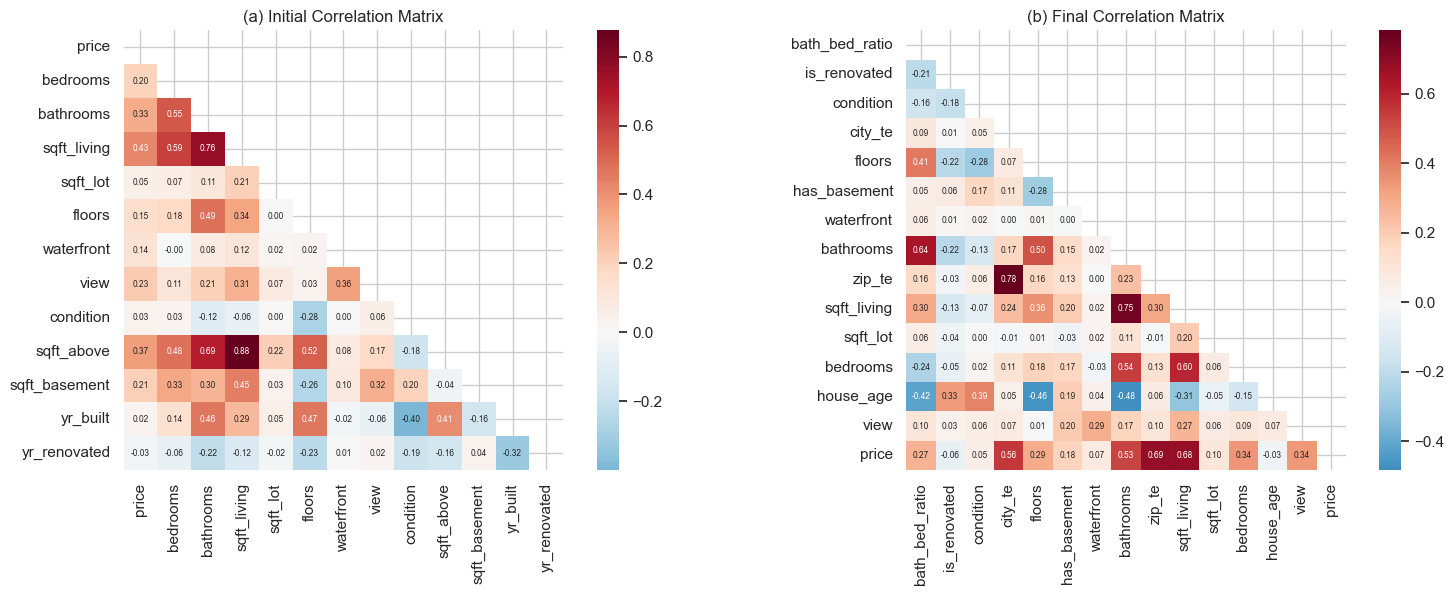

In [19]:
# Final correlation matrix on the selected features
final_corr = train_df_corr[final_features + ['price']].corr()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Initial correlation matrix on the full feature set
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', annot_kws={"size": 6}, cmap='RdBu_r', center=0,
            square=True, ax=axes[0])
axes[0].set_title('(a) Initial Correlation Matrix')

# (b) Correlation matrix after feature selection
sns.heatmap(final_corr, mask=np.triu(np.ones_like(final_corr, dtype=bool)),
            annot=True, fmt='.2f', annot_kws={"size": 6}, cmap='RdBu_r', center=0,
            square=True, ax=axes[1])
axes[1].set_title('(b) Final Correlation Matrix')

plt.tight_layout()
plt.savefig('corr_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

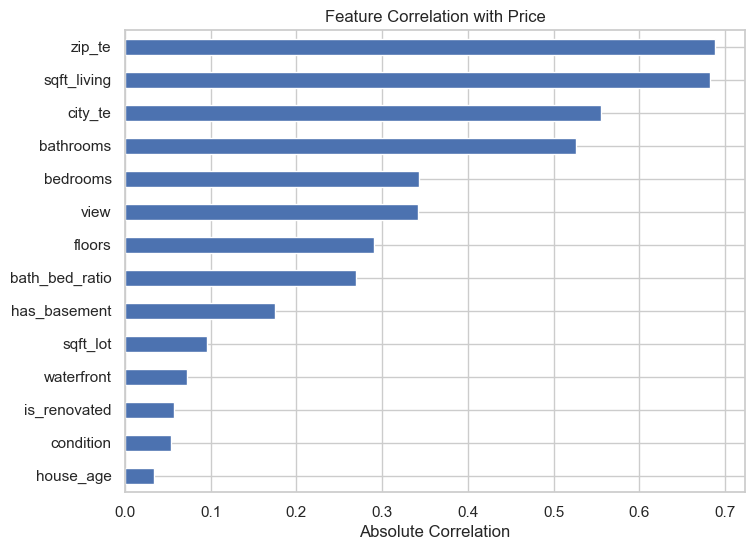

In [20]:
corr_price_final = train_df_corr[final_features + ['price']].corr()['price'].abs().drop('price').sort_values()

plt.figure(figsize=(8, max(6, len(final_features) * 0.35)))
corr_price_final.plot(kind='barh')
plt.title('Feature Correlation with Price')
plt.xlabel('Absolute Correlation')
plt.savefig('feature_correlation_with_price.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Scaling

The following section is for Standardisation (transforming features to have zero mean and unit variance).

In [21]:
X_train_sel = X_train[final_features]
X_test_sel = X_test[final_features]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sel), columns=X_train_sel.columns, index=X_train_sel.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_sel), columns=X_test_sel.columns, index=X_test_sel.index)

print('Scaled train:', X_train_scaled.shape)
print('Scaled test:', X_test_scaled.shape)

Scaled train: (3604, 14)
Scaled test: (901, 14)


# Part 7 — Model Training and Evaluation

Train six diverse base learners (Ridge, Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM), generate 5-fold out-of-fold (OOF) predictions, and build three stacking ensemble variants. All models share the same scaled feature set and the same fixed seed.

## Base Model

1) **Ridge Regression** 
2) **Random Forest** 
3) **Extra Trees** 
4) **Gradient Boosting Regressor (GBR)** 
5) **XGBoost** 
4) **LightGBM** 

### Rationale
Following models are selected to ensure diversity in learning strategies:
- linear modelling
- bagging methods
- boosting methods
- neural networks



In [22]:
base_models = {
    'Ridge': Ridge(alpha=1.0),

    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', random_state=42
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', random_state=42
    ),

    'GBR': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),

    'LightGBM': lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
}

## Baseline Model Training and Evaluation

Each model is trained on the training set and evaluated on the test set to assess predictive performance.

### Evaluation Metrics
The following metrics are used:
1) **$R^2$ (Coefficient of Determination)** 
2) **RMSE (Root Mean Squared Error)** 
3) **MAE (Mean Absolute Error)** 

### Process
1) Each model is trained on the training data  
2) Predictions are generated on the test set  
3) Performance metrics are computed 

In [23]:
# Train each base learner on log-price; evaluate after exponentiating predictions
# back to the original dollar scale.
results = []
for name, model in base_models.items():
    print(f'Training {name}...')
    m = clone(model)
    m.fit(X_train_scaled, y_train_log)            
    pred_log = m.predict(X_test_scaled)
    preds = np.expm1(pred_log)                     

    results.append({
        'Model': name,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results_df)

Training Ridge...
Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training GBR...
Training LightGBM...


,Model,R2,RMSE,MAE
5,LightGBM,0.776059,132082.976944,81037.481283
3,XGBoost,0.765080,135281.950037,80934.431454
1,Random Forest,0.754210,138376.589366,83627.869738
4,GBR,0.753852,138477.251316,82640.782043
2,Extra Trees,0.733635,144051.860921,86086.456214
0,Ridge,0.708026,150817.699788,94765.833315


## Out-of-Fold (OOF) Prediction Generation

To construct a stacking ensemble, out-of-fold (OOF) predictions are generated for each base model using 5-fold cross-validation.

### Process
The training data is split into 5 folds. For each iteration, the model is trained on 4 folds
and the predictions are generated for the remaining unseen fold


The OOF predictions from all base models are combined to form a new feature matrix (`X_meta_train`), which is used to train the meta-learner.
For the test set, predictions are generated in each fold and averaged to produce stable meta-features (`X_meta_test`).

### Rationale
OOF prevents data leakage and ensures that the meta-learner is trained on unbiased predictions.

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(base_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f'Generating OOF for {name}...')
    fold_test = np.zeros((X_test_scaled.shape[0], 5))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
        m = clone(model)
        m.fit(X_train_scaled.iloc[tr_idx], y_train_log.iloc[tr_idx])    # train on log
        train_oof[val_idx, i] = m.predict(X_train_scaled.iloc[val_idx])  # log-space
        fold_test[:, fold] = m.predict(X_test_scaled)                    # log-space

    test_preds[:, i] = fold_test.mean(axis=1)

# OOF predictions are kept in log-space so the meta-learner operates on a single,
# consistent target scale. They are inverted with expm1 only at final evaluation.
X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys(), index=X_train_scaled.index)
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys(), index=X_test_scaled.index)

print('OOF generation complete')

Generating OOF for Ridge...
Generating OOF for Random Forest...
Generating OOF for Extra Trees...
Generating OOF for XGBoost...
Generating OOF for GBR...
Generating OOF for LightGBM...
OOF generation complete


## Stacking Ensemble Variants

Three different meta-learning strategies are implemented and compared.

### Stacking V1: OOF Only
Uses only out-of-fold (OOF) predictions as input features and Ridge regression model is used as the meta-learner  


### Stacking V2: OOF + Passthrough (Ridge)
Combines OOF predictions with the original scaled input features and uses Ridge regression as the meta-learner  


### Stacking V3: OOF + Passthrough (Lasso)
 Same input as V2 (OOF + original features) but uses Lasso regression with cross-validation for automatic feature selection  


In [25]:
# All three meta-learners are trained on log-price and their predictions are
# inverted with expm1 before computing dollar-space metrics.
meta_v1 = Ridge(alpha=1.0)
meta_v1.fit(X_meta_train, y_train_log)
y_pred_v1 = np.expm1(meta_v1.predict(X_meta_test))

X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)

meta_v2 = Ridge(alpha=1.0)
meta_v2.fit(X_meta_train_full, y_train_log)
y_pred_v2 = np.expm1(meta_v2.predict(X_meta_test_full))

meta_v3 = LassoCV(cv=5, random_state=42, max_iter=10000)
meta_v3.fit(X_meta_train_full, y_train_log)
y_pred_v3 = np.expm1(meta_v3.predict(X_meta_test_full))

print('Stacking V1 (OOF only)')
print(f'  R2:   {r2_score(y_test, y_pred_v1):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v1)):.0f}')

print('\nStacking V2 (OOF + passthrough, Ridge)')
print(f'  R2:   {r2_score(y_test, y_pred_v2):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v2)):.0f}')

print('\nStacking V3 (OOF + passthrough, Lasso) ')
print(f'  R2:   {r2_score(y_test, y_pred_v3):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v3)):.0f}')

Stacking V1 (OOF only)
  R2:   0.7867
  RMSE: 128916

Stacking V2 (OOF + passthrough, Ridge)
  R2:   0.8015
  RMSE: 124340

Stacking V3 (OOF + passthrough, Lasso) 
  R2:   0.8003
  RMSE: 124739


## Meta-Learner Coefficient Analysis

### Ridge Meta-Learner (Stacking V2, whose performance is better than V1)
### Lasso Meta-Learner (Stacking V3)


In [26]:
print('V2 Meta-learner coefficients')
for name, coef in zip(base_models.keys(), meta_v2.coef_):
    print(f'  {name}: {coef:.4f}')

print('\nV3 Lasso non-zero coefficients')
v3_names = list(base_models.keys()) + list(X_train_scaled.columns)
for name, coef in zip(v3_names, meta_v3.coef_):
    if abs(coef) > 0.001:
        print(f'  {name}: {coef:.4f}')

V2 Meta-learner coefficients
  Ridge: -1.0206
  Random Forest: 0.2333
  Extra Trees: 0.1814
  XGBoost: 0.1483
  GBR: 0.0684
  LightGBM: 0.3672

V3 Lasso non-zero coefficients
  Random Forest: 0.2305
  Extra Trees: 0.0358
  XGBoost: 0.1725
  GBR: 0.0559
  LightGBM: 0.4163
  is_renovated: 0.0039
  condition: 0.0114
  floors: 0.0065
  has_basement: -0.0012
  waterfront: 0.0072
  zip_te: 0.0304
  sqft_living: 0.0268
  bedrooms: -0.0038
  view: 0.0097


## Model Comparison: Individual Models vs Stacking Ensembles

The performance of individual base models is compared with multiple stacking variants.


,Model,R2,RMSE,MAE
7,Stacking V2,0.801546,124339.944248,77587.997214
8,Stacking V3,0.800269,124739.341099,77899.044599
6,Stacking V1,0.786669,128916.118116,78841.863269
5,LightGBM,0.776059,132082.976944,81037.481283
3,XGBoost,0.765080,135281.950037,80934.431454
1,Random Forest,0.754210,138376.589366,83627.869738
4,GBR,0.753852,138477.251316,82640.782043
2,Extra Trees,0.733635,144051.860921,86086.456214
0,Ridge,0.708026,150817.699788,94765.833315


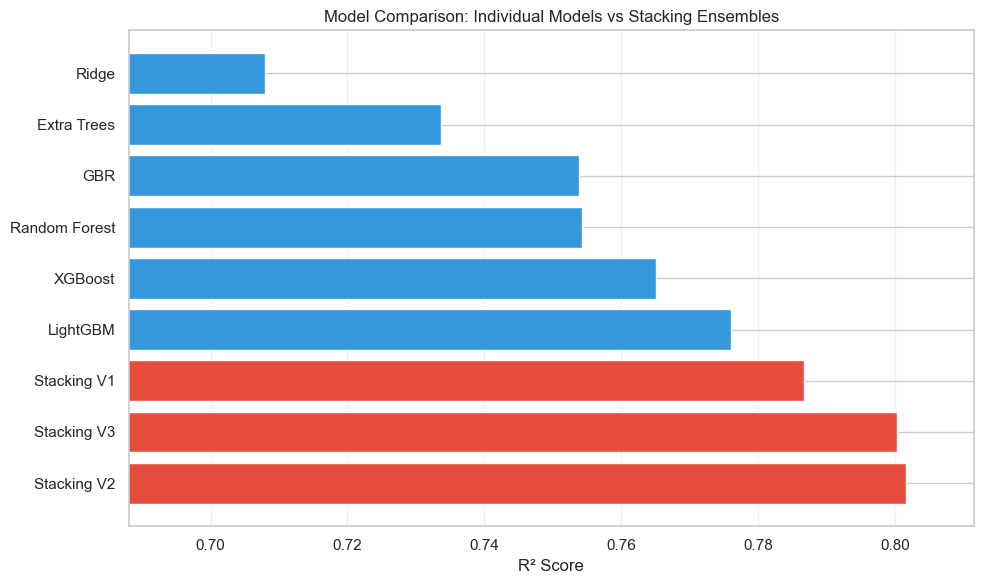

In [27]:
all_results = results.copy()
all_results.append({'Model': 'Stacking V1', 'R2': r2_score(y_test, y_pred_v1), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_v1)), 'MAE': mean_absolute_error(y_test, y_pred_v1)})
all_results.append({'Model': 'Stacking V2', 'R2': r2_score(y_test, y_pred_v2), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_v2)), 'MAE': mean_absolute_error(y_test, y_pred_v2)})
all_results.append({'Model': 'Stacking V3', 'R2': r2_score(y_test, y_pred_v3), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_v3)), 'MAE': mean_absolute_error(y_test, y_pred_v3)})

all_df = pd.DataFrame(all_results).sort_values('R2', ascending=False)
display(all_df)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if 'Stacking' in m else '#3498db' for m in all_df['Model']]
plt.barh(all_df['Model'], all_df['R2'], color=colors)
plt.xlabel('R² Score')
plt.title('Model Comparison: Individual Models vs Stacking Ensembles')
plt.xlim(all_df['R2'].min() - 0.02, all_df['R2'].max() + 0.01)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Part 8  Ablation and Diagnostic Analysis


## Ablation Study
1) Identify the best-performing stacking variant
2) Remove each base model
3) Reattain the stacking model
4) Record the decrease in performance 


Ablation: removing Ridge...
Ablation: removing Random Forest...
Ablation: removing Extra Trees...
Ablation: removing XGBoost...
Ablation: removing GBR...
Ablation: removing LightGBM...


,Removed,R2,RMSE,R2_drop
5,LightGBM,0.777485,131661.711814,0.024060
0,Ridge,0.783892,129752.541358,0.017654
1,Random Forest,0.786266,129037.722833,0.015279
3,XGBoost,0.787357,128708.011355,0.014188
4,GBR,0.787583,128639.622768,0.013962
2,Extra Trees,0.787609,128631.693332,0.013936
6,None (Full),0.801546,124339.944248,0.000000


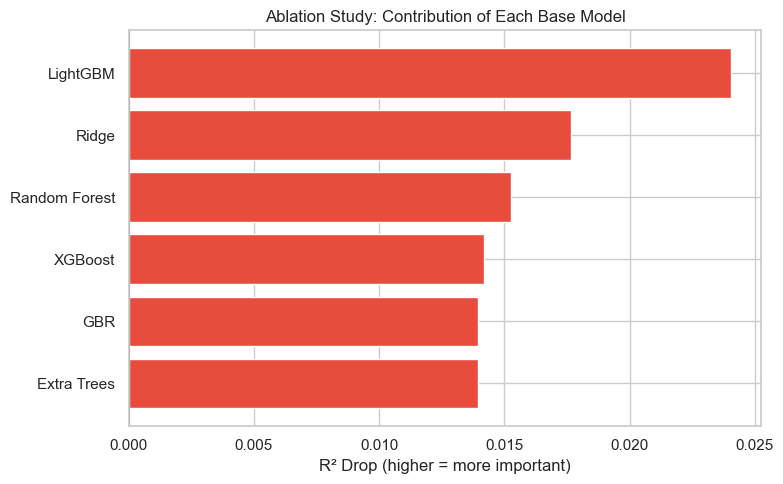

In [28]:
# All ablation meta-learners are trained on log-price and predictions are inverted
# with expm1 before computing R2/RMSE on the dollar scale.
best_v = np.argmax([r2_score(y_test, y_pred_v1),
                    r2_score(y_test, y_pred_v2),
                    r2_score(y_test, y_pred_v3)])
best_stack_preds = [y_pred_v1, y_pred_v2, y_pred_v3][best_v]
best_stack_r2 = r2_score(y_test, best_stack_preds)

ablation_results = []
model_names = list(base_models.keys())

for remove in model_names:
    print(f'Ablation: removing {remove}...')
    keep_idx = [j for j, n in enumerate(model_names) if n != remove]

    X_ab_train = X_meta_train.iloc[:, keep_idx]
    X_ab_test = X_meta_test.iloc[:, keep_idx]

    ab_meta = Ridge(alpha=1.0)
    ab_meta.fit(X_ab_train, y_train_log)
    ab_preds = np.expm1(ab_meta.predict(X_ab_test))

    ablation_results.append({
        'Removed': remove,
        'R2': r2_score(y_test, ab_preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, ab_preds)),
        'R2_drop': best_stack_r2 - r2_score(y_test, ab_preds)
    })

ablation_results.append({
    'Removed': 'None (Full)',
    'R2': best_stack_r2,
    'RMSE': np.sqrt(mean_squared_error(y_test, best_stack_preds)),
    'R2_drop': 0
})

ab_df = pd.DataFrame(ablation_results).sort_values('R2_drop', ascending=False)
display(ab_df)

plt.figure(figsize=(8, 5))
ab_plot = ab_df[ab_df['Removed'] != 'None (Full)'].sort_values('R2_drop')
colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in ab_plot['R2_drop']]
plt.barh(ab_plot['Removed'], ab_plot['R2_drop'], color=colors)
plt.xlabel('R² Drop (higher = more important)')
plt.title('Ablation Study: Contribution of Each Base Model')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('ablation.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance Analysis
The following cell uses LightGBM to estimate feature importance.

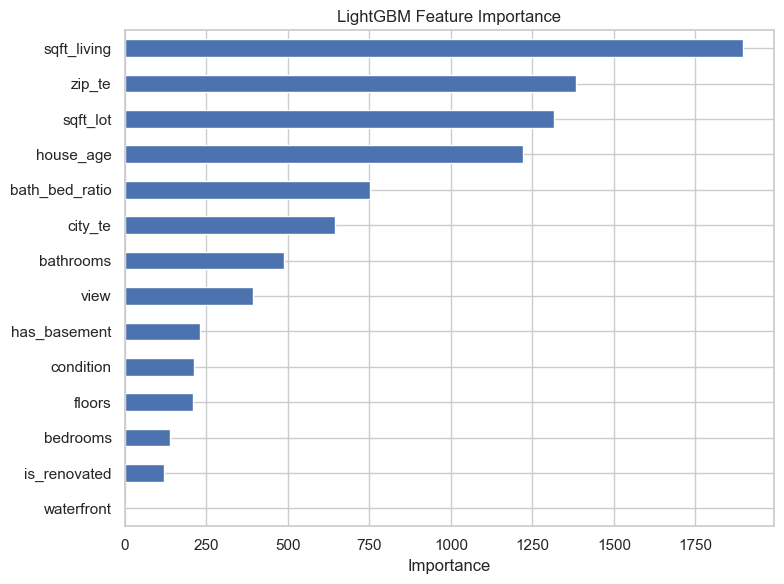

In [29]:
lgb_imp = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42)
lgb_imp.fit(X_train_scaled, y_train)

importances = pd.Series(lgb_imp.feature_importances_, index=X_train_scaled.columns)

plt.figure(figsize=(8, max(6, len(final_features) * 0.35)))
importances.sort_values().plot(kind='barh')

plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance_lgbm.png', dpi=300, bbox_inches='tight')
plt.show()

## Impact of Preprocessing
 Random Forest and XGBoost:
1) **Raw dataset (Before preprocessing)**
2) **Processed dataset (After preprocessing)**


,Stage,Model,R2,RMSE
0,Before,LightGBM,0.527626,265094.914325
1,After,LightGBM,0.776059,132082.976944
2,Before,XGBoost,0.461344,283083.228851
3,After,XGBoost,0.751048,139263.822025


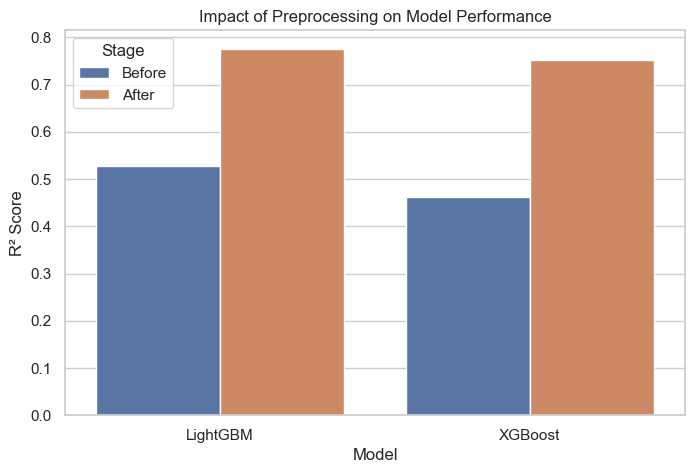

In [30]:
# 'Before' baseline: raw data, raw target (no preprocessing, no log).
# 'After' uses the full pipeline including log-transformed target.
df_raw = df_original.copy()
df_raw = df_raw[df_raw['price'] > 0]   # drop zero-price rows so the baseline is comparable
df_raw = df_raw.drop(columns=['street', 'city', 'date', 'country', 'statezip'])

X_raw = df_raw.drop(columns=['price'])
y_raw = df_raw['price']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42)

compare_results = []

for name, model in [
    ('LightGBM', LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, max_depth=-1, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)),
    ('XGBoost', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                             objective='reg:squarederror', random_state=42)),
]:
    # Before: raw features, raw target
    m = clone(model)
    m.fit(X_train_raw, y_train_raw)
    p = m.predict(X_test_raw)
    compare_results.append({
        'Stage': 'Before', 'Model': name,
        'R2': r2_score(y_test_raw, p),
        'RMSE': np.sqrt(mean_squared_error(y_test_raw, p))
    })

    # After: full preprocessing + log-target
    m2 = clone(model)
    m2.fit(X_train_scaled, y_train_log)
    p2 = np.expm1(m2.predict(X_test_scaled))
    compare_results.append({
        'Stage': 'After', 'Model': name,
        'R2': r2_score(y_test, p2),
        'RMSE': np.sqrt(mean_squared_error(y_test, p2))
    })

compare_df = pd.DataFrame(compare_results)
display(compare_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=compare_df, x='Model', y='R2', hue='Stage')
plt.title('Impact of Preprocessing on Model Performance')
plt.ylabel('R² Score')
plt.savefig('model_performance_before_after_preprocessing.png', dpi=300, bbox_inches='tight')
plt.show()

## Residual Analysis of Best Stacking Model

Residual analysis was conducted using V2.
1) **Predicted vs Actual plot**
2) **Residual plot**
3) **Residual distribution**


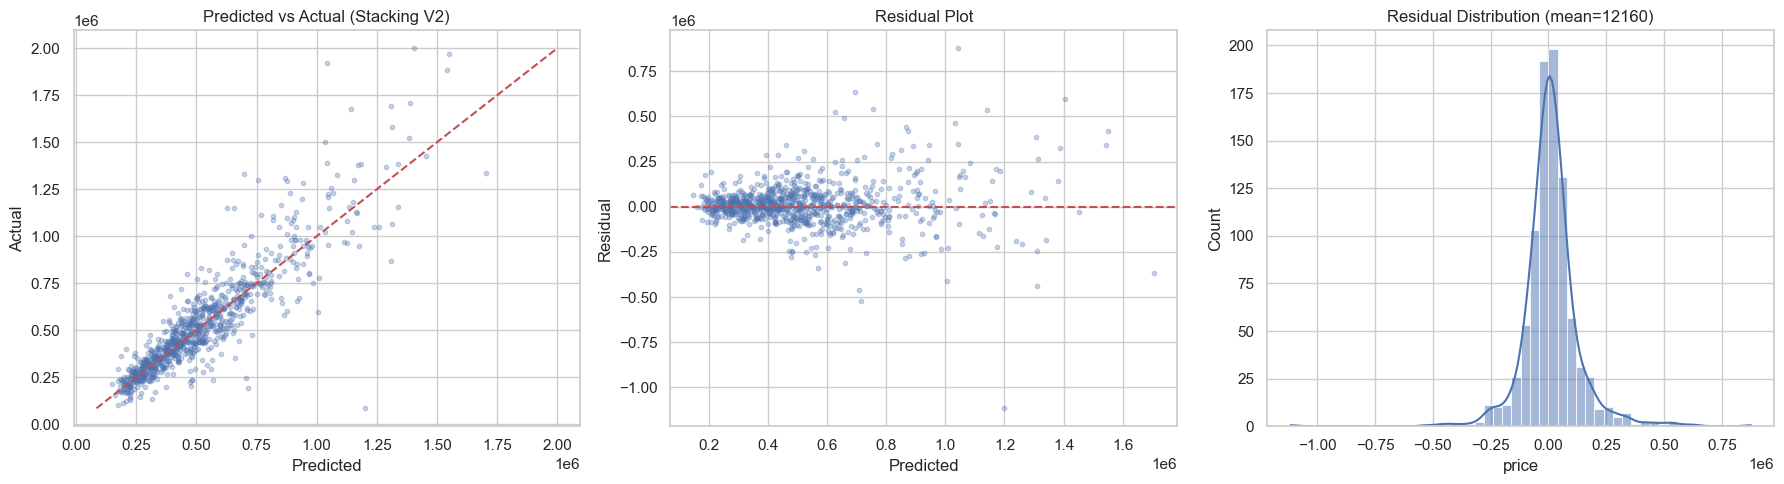

In [31]:
best_preds = [y_pred_v1, y_pred_v2, y_pred_v3][best_v]
best_name = ['V1', 'V2', 'V3'][best_v]
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_preds, y_test.values, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Predicted vs Actual (Stacking {best_name})')

axes[1].scatter(best_preds, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

sns.histplot(residuals, bins=50, kde=True, ax=axes[2])
axes[2].set_title(f'Residual Distribution (mean={residuals.mean():.0f})')

plt.tight_layout()
plt.savefig('model_diagnostics_stacking.png', dpi=300, bbox_inches='tight')
plt.show()